In [66]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [68]:
df = pd.read_csv("../data/raw_ecommerce_sales.csv")

In [43]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_City,Customer_Age,Product,Category,Quantity,Unit_Price,Discount_Percent,Payment_Method,Order_Status,Customer_Rating
0,ORD000001,10-07-2026,CUST01441,Chennai,35.0,USB-C Fast Charger,Electronics,2,932.92,15.7,Debit Card,Delivered,2.5
1,ORD000002,26-03-2026,CUST01522,Delhi,19.0,Resistance Bands,Sports & Fitness,1,588.71,7.6,Debit Card,Delivered,4.3
2,ORD000003,05-04-2026,CUST00045,Mangaluru,30.0,Indian History,Books,2,534.58,4.1,Cash on Delivery,Delivered,4.1
3,ORD000004,01-01-2026,CUST01542,Surat,24.0,Men's Casual Shirt,Fashion,1,1162.86,16.1,UPI,Delivered,3.2
4,ORD000005,25-04-2026,CUST01584,Bengaluru,29.0,Resistance Bands,Sports & Fitness,1,608.37,16.8,UPI,Delivered,5.0


In [44]:
df.shape

(6216, 13)

In [45]:
df.describe()

,Customer_Age,Quantity,Unit_Price,Discount_Percent,Customer_Rating
count,6105.000000,6216.000000,6216.000000,6179.000000,5157.000000
mean,30.638002,1.697716,1129.958760,9.342353,3.998623
std,7.446159,0.765613,755.464909,4.076928,0.695307
min,18.000000,-2.000000,-99.000000,0.000000,0.000000
25%,25.000000,1.000000,595.130000,6.600000,3.600000
50%,31.000000,2.000000,818.005000,9.400000,4.000000
75%,36.000000,2.000000,1517.290000,12.100000,4.500000
max,58.000000,5.000000,3688.580000,23.800000,6.000000


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6216 entries, 0 to 6215
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          6216 non-null   str    
 1   Order_Date        6216 non-null   str    
 2   Customer_ID       6216 non-null   str    
 3   Customer_City     6167 non-null   str    
 4   Customer_Age      6105 non-null   float64
 5   Product           6192 non-null   str    
 6   Category          6216 non-null   str    
 7   Quantity          6216 non-null   int64  
 8   Unit_Price        6216 non-null   float64
 9   Discount_Percent  6179 non-null   float64
 10  Payment_Method    6192 non-null   str    
 11  Order_Status      6216 non-null   str    
 12  Customer_Rating   5157 non-null   float64
dtypes: float64(4), int64(1), str(8)
memory usage: 631.4 KB


In [47]:
df["Payment_Method"].value_counts()

Payment_Method
UPI                 2913
Credit Card         1158
Debit Card           694
Cash on Delivery     639
Net Banking          434
Wallet               312
 UPI                   9
Credit card            6
upi                    6
Cash On Delivery       6
credit card            5
Debit card             4
Net banking            2
cash on delivery       2
debit card             1
net banking            1
Name: count, dtype: int64

In [69]:
df.duplicated().sum()

np.int64(16)

In [70]:
df.isna().sum()

Order_ID               0
Order_Date             0
Customer_ID            0
Customer_City         49
Customer_Age         111
Product               24
Category               0
Quantity               0
Unit_Price             0
Discount_Percent      37
Payment_Method        24
Order_Status           0
Customer_Rating     1059
dtype: int64

In [50]:
df = df.drop_duplicates()

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df["Category"]=df["Category"].str.strip().str.title()

In [53]:
df = df[df["Quantity"] > 0]

In [54]:
df["Order_Date"]=pd.to_datetime(df["Order_Date"],errors="coerce")

In [55]:
df.to_csv("../output/clean_commerce_sales.csv", index=False)

In [56]:
print(type(df))

<class 'pandas.DataFrame'>


In [57]:
df.groupby("Customer_City")["Discount_Percent"].sum().sort_values(ascending=False).head(10)

Customer_City
Delhi        5967.3
Hyderabad    4809.8
Bengaluru    4736.3
Chennai      4730.2
Mumbai       4696.2
Surat        4095.1
Pune         3900.4
Ahmedabad    3744.0
Kolkata      3644.2
Kochi        3078.4
Name: Discount_Percent, dtype: float64

In [58]:
df.groupby("Product")["Quantity"].sum().sort_values(ascending=False).head(10)

Product
USB-C Fast Charger     380
Cotton T-Shirt         366
Cooking Oil 5L         363
Basmati Rice 5kg       363
Water Bottle           319
Men's Casual Shirt     308
Coffee 500g            285
Wireless Earbuds       264
Atomic Habits          261
Power Bank 20000mAh    260
Name: Quantity, dtype: int64

In [81]:
df["Revenue"]=(df["Quantity"]*df["Unit_Price"])*(1-df["Discount_Percent"]/100)

In [82]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_City',
       'Customer_Age', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Discount_Percent', 'Payment_Method', 'Order_Status', 'Customer_Rating',
       'Month', 'Revenue'],
      dtype='str')

In [83]:
df.groupby("Customer_City")["Revenue"].sum().sort_values(ascending=False).head(10)

Customer_City
Delhi        1.102761e+06
Mumbai       9.334214e+05
Chennai      9.011506e+05
Hyderabad    8.522737e+05
Bengaluru    8.397075e+05
Pune         7.292215e+05
Surat        7.199133e+05
Kolkata      6.746360e+05
Ahmedabad    6.655049e+05
Kochi        5.610396e+05
Name: Revenue, dtype: float64

In [84]:
df["Order_Date"]=pd.to_datetime(df["Order_Date"],errors="coerce")

In [85]:
df["Month"]= df["Order_Date"].dt.to_period("M")

In [86]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_City',
       'Customer_Age', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Discount_Percent', 'Payment_Method', 'Order_Status', 'Customer_Rating',
       'Month', 'Revenue'],
      dtype='str')

In [87]:
monthly_sales = (
    df.groupby("Month")["Revenue"]
    .sum()
    )
monthly_sales

Month
2025-01    110101.34888
2025-02    151143.70295
2025-03    141199.22071
2025-04    125582.96573
2025-05    157256.60967
2025-06    139155.90278
2025-07    132907.26372
2025-08    134934.41837
2025-09    121745.30136
2025-10    101866.90721
2025-11    110689.57443
2025-12    119008.60278
2026-01    219468.86155
2026-02    222910.12166
2026-03    231433.27629
2026-04    223563.44004
2026-05    249803.28315
2026-06    239989.63256
2026-07    190891.96984
2026-08    209087.86273
2026-09    174497.79014
2026-10    231901.89469
2026-11    224798.37318
2026-12    204091.37217
Freq: M, Name: Revenue, dtype: float64

In [34]:
category_sales = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='Month'>

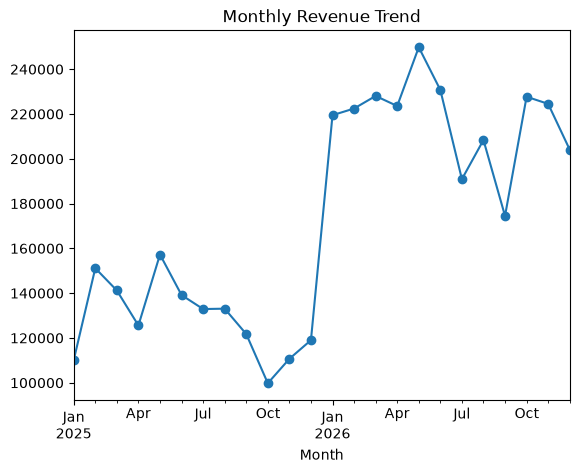

In [35]:
monthly_sales.plot(kind="line" , marker = "o",title ="Monthly Revenue Trend")

In [88]:
top_products = df.groupby("Product")["Revenue"].sum().sort_values(ascending= False).head(10).sort_values(ascending=True).tail(10)

<Axes: title={'center': 'Top 10 Products By Revenue'}, ylabel='Product'>

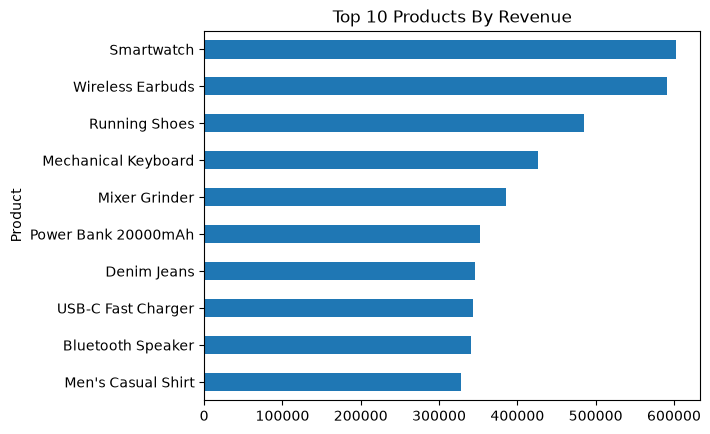

In [89]:
top_products.plot(kind ="barh",title="Top 10 Products By Revenue")

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
corr = df[["Quantity", "Unit_Price", "Discount_Percent", "Revenue"]].corr()

<Axes: >

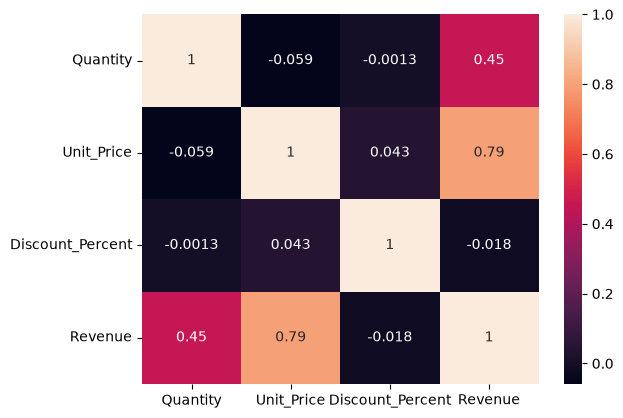

In [92]:
sns.heatmap(corr,annot=True)

<Axes: xlabel='Discount_Percent', ylabel='Revenue'>

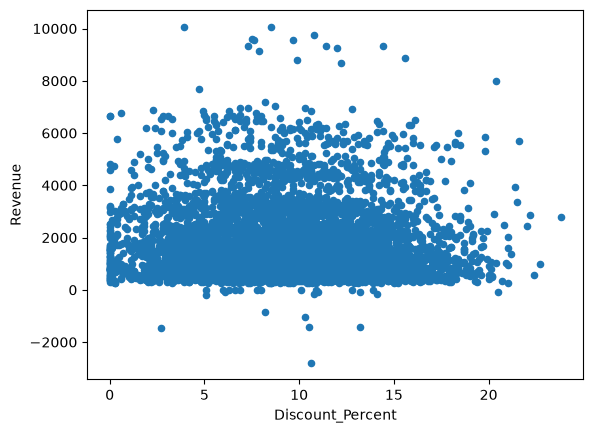

In [93]:
df.plot(kind="scatter",x="Discount_Percent",y="Revenue")

In [94]:
df.to_csv("../output/analyzed_ecommerce_sales.csv", index=False)